# **========== Analisis Kualitas Data Transaksi Keuangan ==========**

## **Import Library**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## **Business Understanding**

### **Business Objective**


Analisis pada dataset Dirty Financial Transactions bertujuan untuk membantu pihak manajemen atau analis dalam memahami pola transaksi keuangan sekaligus mengidentifikasi permasalahan kualitas data yang dapat memengaruhi pengambilan keputusan bisnis. Fokus utama analisis ini mencakup evaluasi nilai transaksi, jumlah transaksi, pola keuntungan dan kerugian, serta deteksi anomali seperti transaksi bernilai ekstrem, data hilang (missing values), dan ketidakkonsistenan data.

Dataset ini merepresentasikan transaksi keuangan yang belum sepenuhnya bersih (dirty data), sehingga diperlukan pendekatan analitik untuk menilai kelayakan data sebelum digunakan dalam analisis lanjutan. Melalui analisis ini, diharapkan dapat diketahui transaksi mana yang berkontribusi positif terhadap profit, transaksi yang berpotensi menimbulkan kerugian, serta aspek kualitas data yang harus diperbaiki agar laporan keuangan menjadi lebih akurat dan andal.

### **Assess Situation**


Situasi bisnis yang melatarbelakangi analisis ini adalah banyaknya data transaksi keuangan yang tercatat secara digital namun memiliki kualitas yang kurang baik. Permasalahan seperti nilai profit yang hilang, data transaksi yang tidak konsisten, serta adanya nilai ekstrem pada nominal transaksi dapat menyebabkan kesalahan interpretasi dalam laporan keuangan dan analisis performa bisnis.

Dalam kondisi ini, pihak pengambil keputusan membutuhkan pemahaman yang jelas mengenai kondisi aktual data transaksi sebelum digunakan untuk evaluasi kinerja atau perencanaan strategis. Keberadaan transaksi dengan nilai kerugian besar serta variasi nominal transaksi yang sangat lebar menunjukkan perlunya analisis data yang sistematis. Oleh karena itu, analisis ini dilakukan untuk menilai kondisi data, mengidentifikasi potensi risiko akibat kualitas data yang buruk, serta menghasilkan insight yang dapat digunakan sebagai dasar perbaikan pengelolaan data dan pengambilan keputusan keuangan yang lebih tepat.

### **Analytic Goals Project Plan**

Rencana proyek analisis ini mencakup tahapan terstruktur mulai dari pemahaman data hingga penyajian hasil analisis, yaitu:

* Pengumpulan dan Eksplorasi Data (Data Understanding)
* Pemeriksaan dan Pembersihan Data (Data Preparation)
* Analisis Data Transaksi (Data Analysis)
* Visualisasi Data dan Penyusunan Laporan
* Penyusunan kesimpulan berdasarkan temuan

Tujuan utama dari analisis data ini adalah menghasilkan insight yang dapat digunakan untuk meningkatkan kualitas data transaksi dan mendukung pengambilan keputusan keuangan. Secara spesifik, tujuan yang ingin dicapai adalah:

* Mengidentifikasi pola dan distribusi transaksi keuangan
* Mengidentifikasi transaksi bernilai ekstrem (outliers)
* Mengevaluasi kualitas data (missing, inkonsisten, duplikasi)
* Menyajikan visualisasi data yang informatif dan mudah dipahami
* Menyajikan visualisasi data yang informatif dan mudah dipahami
* Menyediakan dasar evaluasi dan perbaikan pengelolaan data keuangan

## **Data Understanding**

### **Memuat Dataset**

Sumber dataset yang digunakan adalah Dirty Financial Transactions, yang berisi data transaksi keuangan dengan berbagai permasalahan kualitas data. Dataset ini digunakan untuk menganalisis pola transaksi sekaligus mengevaluasi kelayakan data sebelum digunakan dalam analisis keuangan lebih lanjut.



In [3]:
file = '/content/drive/MyDrive/sisfor/dirty_financial_transactions.csv'

df = pd.read_csv(file)
df

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed
...,...,...,...,...,...,...,...,...
99995,NaN,2021-10-06,C1743,Headphones,-8.0,240.0032380562687,PayPal,complete
99996,T99997,2024-08-25,C4830,Smartphone,NaN,503.82951729633896,credit card,Completed
99997,T99998,2023-13-01,C280,Laptop,-10.0,NaN,PayPal,completed
99998,T99999,2020-07-12,C4059,Headphones,10.0,NaN,PayPal,Completed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Deskripsi Data**

#### **Informasi** Dasar

Berdasarkan data yang digunakan, dataset ini memiliki sejumlah baris transaksi dan beberapa kolom utama yang merepresentasikan nilai transaksi, jumlah, serta profit atau kerugian.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   object 
 1   Transaction_Date    95120 non-null   object 
 2   Customer_ID         95122 non-null   object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            94981 non-null   float64
 5   Price               66503 non-null   object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  83321 non-null   object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 100000 Baris dan 8 Kolom

#### **Informasi Lanjutan**

> Add blockquote



Dataset terdiri dari 100.000 data transaksi dengan 8 kolom. Sebagian besar kolom masih bertipe object, hanya kolom Quantity yang sudah bertipe numerik. Kolom seperti Price dan Transaction_Date seharusnya bertipe numerik dan tanggal. Kondisi ini mengindikasikan perlunya konversi tipe data sebelum analisis lanjutan dilakukan. Kolom Quantity memiliki data kosong dan berpotensi mengandung nilai tidak wajar dan Dataset belum sepenuhnya siap digunakan untuk analisis langsung.



#### **Informasi Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
count,94982,95120,95122,100000,94981.000000,66503,100000,83321
unique,94040,1861,5000,46,NaN,65757,7,5
top,T13244,2023-13-01,C4347,Tablet,NaN,-882.8581558218868,Credit Card,Failed
freq,3,31834,37,18444,NaN,3,14433,16795
mean,NaN,NaN,NaN,NaN,183.883914,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,299.292365,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-10.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,-3.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,327.000000,NaN,NaN,NaN


1. Count (Kelengkapan Data)

Analisis kelengkapan data dilakukan
untuk mengidentifikasi kolom yang memiliki nilai hilang (missing values). Keberadaan data yang tidak lengkap dapat memengaruhi hasil analisis dan perlu ditangani sebelum analisis lanjutan dilakukan.

Kesimpulan :

Kolom Price dan Transaction_Status memiliki tingkat missing value paling tinggi dan berpotensi memengaruhi analisis keuangan.

---

2. Mean vs Median (Distribusi Data)

Perbandingan nilai rata-rata (mean) dan median digunakan untuk melihat kecenderungan distribusi data transaksi. Perbedaan yang signifikan mengindikasikan adanya nilai ekstrem yang memengaruhi rata-rata.

* Kolom Quantity
* Mean (rata-rata): 183,88
* Median: 6
Kesimpulan :

Perbedaan yang sangat jauh antara mean dan median menunjukkan distribusi tidak normal (right-skewed) dan adanya nilai ekstrem (outliers) pada jumlah pembelian.

---

3. Min dan Max (Validasi Logika)
* Quantity
* Min = -10
* Max = 1000

Kesimpulan:

Nilai Quantity negatif (-10) tidak logis secara bisnis menyebabkan indikasi data error dan nilai maksimum 1000 menunjukkan transaksi pembelian dalam jumlah sangat besar

---

4. Standar Deviasi (std) - Variabilitas Data
* Quantity: 299,29

Kesimpulan :

Nilai standar deviasi yang lebih besar dari rata-rata menunjukkan variasi data yang sangat tinggi, menandakan perbedaan ekstrem antar transaksi.

### **Verifikasi Kualitas Data**

#### **Data Type Check**

Tahap ini bertujuan untuk memastikan bahwa setiap kolom memiliki tipe data yang sesuai, sehingga analisis dan visualisasi yang dihasilkan menjadi akurat. Sebagian besar kolom bertipe object, kolom Price seharusnya numerik namun masih bertipe object dan kolom Transaction_Date belum dikonversi ke tipe tanggal

In [ ]:
df.dtypes

,0
Transaction_ID,object
Transaction_Date,object
Customer_ID,object
Product_Name,object
Quantity,float64
Price,object
Payment_Method,object
Transaction_Status,object


#### **Incosistent Values**

1. **Payment_Method**

Pada kolom ini, dapat terlihat format penulisan tidak konsisten dengan format yang sama. Semua memiliki format yang berbeda-beda. Maka hal ini perlu ditangani dengan cara kita akan menyamakan format nya menggunakan huruf kecil dengan tanda garis bawah(_) sebagai pengganti spasi.

In [ ]:
print(df['Payment_Method'].unique())

['pay pal' 'creditcard' 'credit card' 'PayPal' 'Cash' 'PayPal '
 'Credit Card']


2. **Transaction_Status**

Pada kolom ini juda terlihat format penulisan tidak konsisten dengan format yang sama. Semua memiliki format yang berbeda-beda. Maka hal ini perlu ditangani dengan cara kita akan menyamakan format nya menggunakan huruf kecil atau format penulisan yang sama.

In [ ]:
print(df['Transaction_Status'].unique())

[nan 'Pending' 'completed' 'Completed' 'complete' 'Failed']


#### **Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom. Dan terlihat bahwa kolom:

* Transaction_ID

  > Memiliki missing values sekitar 5,0%.

* Transaction_Date

  > Memiliki missing values sekitar 4,9%.

* Customer_ID

  > Memiliki missing values sekitar 4,9%.

* Price

  > Memiliki missing values sekitar 33,5%.

* Transaction Status

  > Memiliki missing values sekitar 16,7%

* Quantity

  > Memiliki missing values sekitar 5,0%

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction_ID,5.018
Transaction_Date,4.880
Customer_ID,4.878
Product_Name,0.000
Quantity,5.019
Price,33.497
Payment_Method,0.000
Transaction_Status,16.679


#### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
3544,T1579,NaN,C2854,Headphones,4.0,978.806380519704,credit card,completed
4816,T4817,2023-13-01,C756,Laptop,170.0,-461.44380335792755,Cash,NaN
5455,T5456,2022-11-01,C1548,Tablet,530.0,-706.4750815495283,PayPal,Pending
5938,T5939,2023-04-14,C2656,Laptop,6.0,NaN,Cash,complete
8125,T8126,2021-05-25,C2396,Smartphone,-4.0,335.9920520635594,PayPal,completed
...,...,...,...,...,...,...,...,...
99674,T47093,2023-13-01,C4823,Tablet,-6.0,-522.4003199263182,creditcard,Completed
99786,T15545,2023-13-01,C2823,Laptop,3.0,NaN,pay pal,completed
99866,T6571,2023-13-01,C4483,Smartphone,2.0,421.99494928905284,PayPal,completed
99984,NaN,2022-01-26,C4753,Laptop,480.0,-558.7481358840021,Cash,completed


Terdapat duplikasi Transaction_ID, di mana satu ID transaksi muncul lebih dari satu kali.

* Transaction_ID unik: 94.040
* Total Transaction_ID tersedia: 94.982

yang berarti selisih yang unik dan tersedia adalah data yang hanya terbaca 1 kali atau kosong.

#### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset dan terlihat kolom Quantity memiliki outlier signifikan yaitu nilai negatif dan nilai sangat besar (hingga 1000) yang memengaruhi rata-rata dan mengganggu visualisasi distribusi.

In [ ]:

results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Quantity,6.273


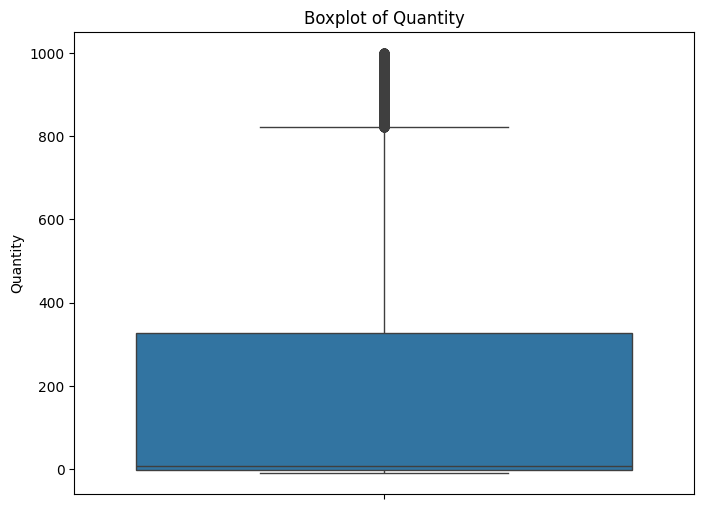

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')
plt.show()

## **Eksplorasi Data (EDA)**

### **Comparison/Perbandingan**

* Analisis :

> Perbandingan dilakukan untuk melihat jumlah transaksi berdasarkan metode pembayaran (Payment_Method)..

* Tujuan :

> Mengidentifikasi wilayah mana yang memberikan kontribusi pendapatan terbesar dan membandingkan performa antar wilayah secara langsung.

* Visualisasi :

> Bar Chart (Grafik Batang).

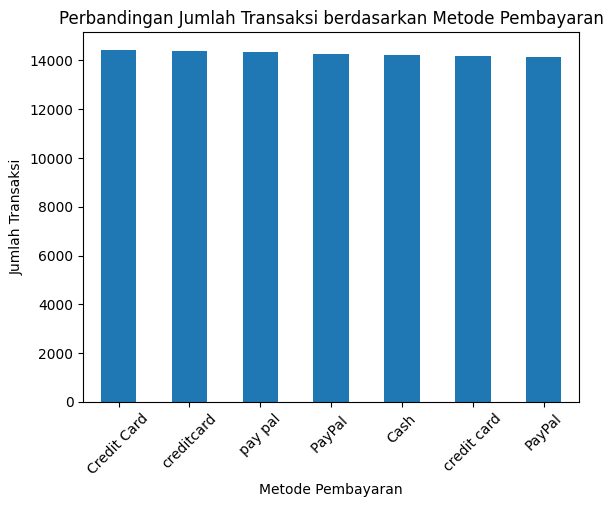

In [ ]:

payment_counts = df['Payment_Method'].value_counts()

plt.figure()
payment_counts.plot(kind='bar')
plt.title('Perbandingan Jumlah Transaksi berdasarkan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()

### **Composition/Komposisi**

* Analisis :

> Komposisi dilakukan untuk melihat proporsi status transaksi (Transaction_Status) terhadap keseluruhan data transaksi. Dominasi transaksi yang berhasil menunjukkan operasional bisnis berjalan cukup baik. Namun, keberadaan transaksi yang pending dan dibatalkan dalam jumlah besar dapat menjadi indikasi adanya kendala pada proses pembayaran, stok, atau sistem.

* Tujuan :

> Visualisasi menunjukkan bahwa status “Completed” mendominasi proporsi transaksi, namun terdapat persentase yang cukup signifikan pada status “Pending” dan “Cancelled”.

* Visualisasi :

> Pie Chart.

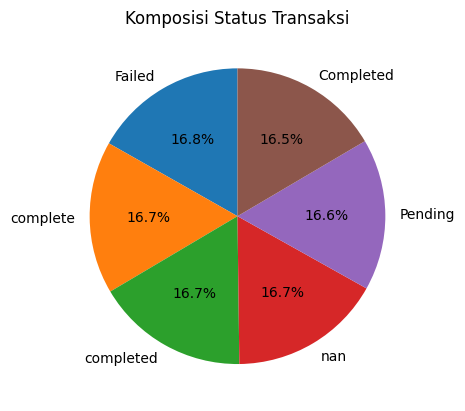

In [ ]:

status_counts = df['Transaction_Status'].value_counts(dropna=False)

plt.figure()
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Komposisi Status Transaksi')
plt.ylabel('')
plt.show()

### **Distribution/Distribusi**

* Analisis :

> Distribusi dilakukan pada Quantity (jumlah barang yang dibeli) untuk memahami pola pembelian pelanggan.

* Insight :

> Distribusi data tidak merata (right-skewed), di mana sebagian besar transaksi memiliki quantity kecil, namun terdapat transaksi dengan jumlah sangat besar. Kondisi ini menyebabkan nilai rata-rata (mean) menjadi jauh lebih besar dibandingkan median. Artinya, sebagian kecil transaksi dengan quantity ekstrem memengaruhi keseluruhan distribusi data. Dari sudut pandang analisis, data ini mengandung outlier yang perlu ditangani agar tidak menghasilkan kesimpulan yang menyesatkan.

* Visualisasi :

> Histogram.

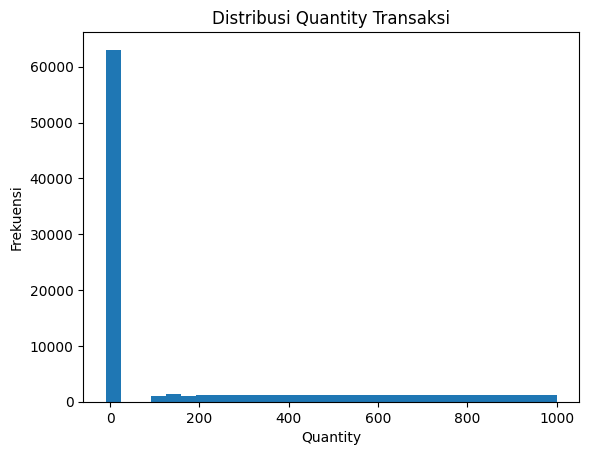

In [ ]:

plt.figure()
df['Quantity'].dropna().plot(kind='hist', bins=30)
plt.title('Distribusi Quantity Transaksi')
plt.xlabel('Quantity')
plt.ylabel('Frekuensi')
plt.show()


### **Relationship/Hubungan**

* Analisis :

> Analisis hubungan dilakukan antara Quantity dan Price untuk melihat keterkaitan jumlah pembelian dengan nilai transaksi.

* Insight :

> Hasil heatmap menunjukkan adanya korelasi positif lemah hingga sedang antara Quantity dan Price, yang berarti peningkatan jumlah barang tidak selalu diikuti oleh peningkatan nilai transaksi secara signifikan. Insight ini mengindikasikan bahwa harga produk bervariasi, sehingga transaksi dengan quantity kecil tetap bisa memiliki nilai transaksi besar jika harga produk tinggi. Sebaliknya, pembelian dalam jumlah besar tidak selalu bernilai tinggi jika harga produk relatif murah. Hubungan ini penting untuk strategi penetapan harga dan analisis perilaku pembelian pelanggan.

* Visualisasi :

> Heatmap.

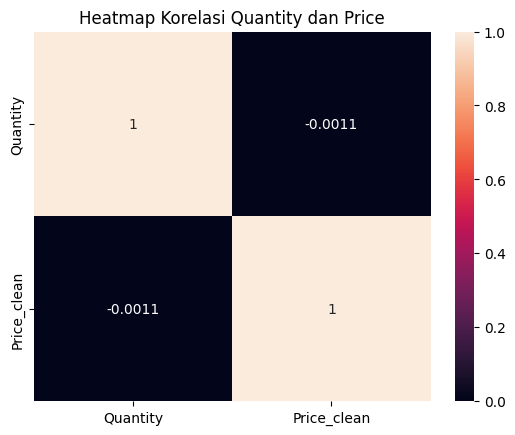

In [ ]:

# Membersihkan kolom Price agar numerik
df['Price_clean'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Price_clean'] = pd.to_numeric(df['Price_clean'], errors='coerce')

# Korelasi
corr_data = df[['Quantity', 'Price_clean']].corr()

plt.figure()
sns.heatmap(corr_data, annot=True)
plt.title('Heatmap Korelasi Quantity dan Price')
plt.show()



## **Dara Preparation**

### **Inconsistent Values**

Dimana penulisan dalam data tidak konsisten secara diksi, dimana terdapat beberapa data yang bernilai sama dengan identitas yang berbeda karna penulisan saat proses input dan proses ini diperbaiki dengan mengganti semua singkatan menjadi kalimat yang jelas dan mengubah huruf yang tidak konsisten menjadi konsisten agar mempermudah proses pengolahan informasi dan penulisan menjadi konsisten.

In [37]:
# Menyerentakkan penulisan

mapping = {
   'pay pal' : 'PayPal',
   'creditcard' : 'Credit Card',
   'credit card' : 'Credit Card',
   'PayPal' : 'PayPal',
   'PayPal ' : 'PayPal',
   'Credit Card' : 'Credit Card'
}

df["Payment_Method"] = df["Payment_Method"].replace(mapping)

In [38]:
print(df['Payment_Method'].unique())

['PayPal' 'Credit Card' 'Cash']


In [39]:
# Menyerentakkan penulisan

mapping = {
  'completed' :  'Completed',
  'complete' :  'Completed'
}

df["Transaction_Status"] = df["Transaction_Status"].replace(mapping)

In [23]:
print(df["Transaction_Status"].unique())

[nan 'Pending' 'completed' 'Completed' 'complete' 'Failed']


### **Missing Values**

Penanganan missing values dilakukan dengan mempertimbangkan jenis dan persentase data yang hilang pada setiap kolom. Kolom Transaction_ID dan Customer_ID dihapus barisnya karena berfungsi sebagai identifier dan tidak dapat diimputasi secara statistik. Kolom numerik seperti Price dan Quantity ditangani menggunakan imputasi median karena memiliki potensi outlier dan untuk menjaga stabilitas distribusi data. Sementara itu, kolom Transaction_Date dan Transaction_Status ditangani menggunakan imputasi modus agar pola data tetap terjaga tanpa mengurangi jumlah observasi secara signifikan.

---

1. Transaction_ID (±5.0%)
  
Metode : Hapus baris

Alasan :

* Transaction_ID adalah identifier unik

* Tidak bisa diimputasi (tidak ada makna statistik)

* Jumlah missing kecil (<10%)

In [24]:
df = df.dropna(subset=["Transaction_ID"])

2. Transaction_Date (±4.9%)

Metode: Imputasi modus (tanggal paling sering)

Alasan:

* Missing relatif kecil

* Menghapus data akan mengurangi jumlah transaksi

* Modus mempertahankan pola waktu transaksi

In [25]:
df["Transaction_Date"] = df["Transaction_Date"].fillna(
    df["Transaction_Date"].mode()[0]
)

/tmp/ipykernel_303/2396072672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Transaction_Date"] = df["Transaction_Date"].fillna(


3. Customer_ID (±4.9%)

Metode: Hapus baris

Alasan:

* Customer_ID adalah identifier

* Tidak bisa diisi dengan mean/median/modus

* Missing kecil dan aman dihapus

In [26]:
df = df.dropna(subset=["Customer_ID"])

4. Price (±33.5%)

Metode: Imputasi median

Alasan:

* Persentase missing cukup besar

* Data numerik

* Menghapus 33% data akan merusak dataset

In [27]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df["Price"] = df["Price"].fillna(df["Price"].median())

5. Transaction_Status (±16.7%)

Metode: Imputasi modus

Alasan:

* Data kategorikal

* Modus menjaga konsistensi status transaksi

* Menghapus 16% data tidak disarankan

In [28]:
df["Transaction_Status"] = df["Transaction_Status"].fillna(
    df["Transaction_Status"].mode()[0]
)

6. Quantity (±5.0%)

Metode: Imputasi median

Alasan:

* Data numerik

* Jumlah missing kecil

* Median aman dari pengaruh outlier

In [29]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

Memeriksa kembali Missing Values

In [30]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction_ID,0.0
Transaction_Date,0.0
Customer_ID,0.0
Product_Name,0.0
Quantity,0.0
Price,0.0
Payment_Method,0.0
Transaction_Status,0.0


### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [31]:
# Menghapus duplikasi

df = df.drop_duplicates()
print("Data setelah hapus duplikat:", df.shape)

Data setelah hapus duplikat: (89442, 8)


In [32]:
df[df.duplicated()]

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status


### **Outliers Values**

Dalam penanganan outliers values, sebenarnya dapat di abaikan karna lebih dari 10%, namun penanganan yang diambil dalam kasus ini yaitu metode mengubah outliers menjadi 0 tanpa mengubah jumlah baris dalam data yang dimana bertujuan agar tidak memengaruhi hasil analisis nantinya. Outlier yang terdeteksi pada data ditangani dengan cara mengganti nilainya menjadi 0. Pendekatan ini dipilih karena nilai outlier dianggap tidak valid atau merupakan kesalahan pencatatan, sehingga perlu dinetralkan tanpa menghapus baris data agar struktur dataset tetap utuh.

In [33]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [34]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Quantity,0.0
Price,0.0


# **Visualisasi**

## **BarChart**

**Insight:**

> Bar chart menunjukkan perbandingan jumlah transaksi berdasarkan metode pembayaran. Terlihat bahwa beberapa metode pembayaran digunakan jauh lebih sering dibandingkan yang lain. Ini menandakan adanya preferensi pelanggan terhadap metode pembayaran tertentu.

**Tindakan yang Dapat Dilakukan :**

* Perusahaan dapat mengoptimalkan metode pembayaran yang paling sering digunakan agar proses transaksi lebih cepat dan stabil.

* Memberikan promo atau cashback pada metode pembayaran yang jarang digunakan untuk meningkatkan penggunaannya.

* Mengurangi atau mengevaluasi metode pembayaran yang sangat jarang dipakai.

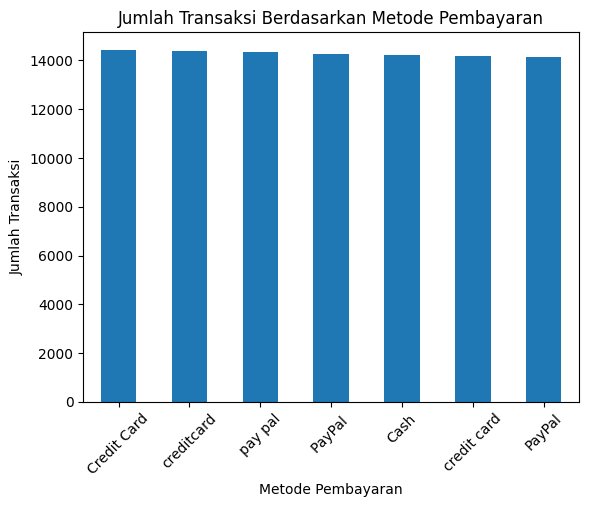

In [4]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure()
payment_counts.plot(kind='bar')

plt.title('Jumlah Transaksi Berdasarkan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()

## **PieChart**

**Insight:**
> Pie chart menunjukkan proporsi status transaksi seperti Completed, Pending, atau Cancelled. Jika sebagian besar transaksi berstatus Completed, berarti sistem transaksi berjalan dengan baik. Namun jika terdapat persentase Pending atau Cancelled yang cukup besar, hal ini dapat menjadi indikasi masalah dalam proses pembayaran atau sistem.

**Tindakan yang Dapat Dilakukan :**

* Mengevaluasi penyebab transaksi Pending atau Cancelled.

* Memperbaiki sistem pembayaran atau proses checkout.

* Memberikan notifikasi atau pengingat kepada pelanggan agar menyelesaikan transaksi yang tertunda.

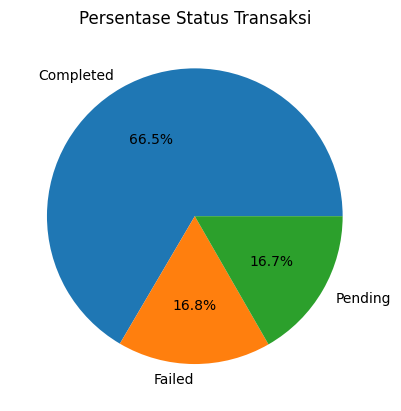

In [49]:
status_counts = df['Transaction_Status'].value_counts()

plt.figure()
status_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Persentase Status Transaksi')
plt.ylabel('')
plt.show()

## **LineChart**

**Insight:**

> Line chart menggambarkan perubahan jumlah transaksi berdasarkan waktu. Grafik ini dapat menunjukkan tren peningkatan atau penurunan transaksi pada periode tertentu.

**Tindakan yang Dapat Dilakukan :**

* Jika terjadi peningkatan transaksi pada periode tertentu, perusahaan dapat meningkatkan stok produk dan kapasitas sistem.

* Jika terjadi penurunan, perusahaan bisa melakukan promosi atau kampanye pemasaran untuk meningkatkan transaksi.

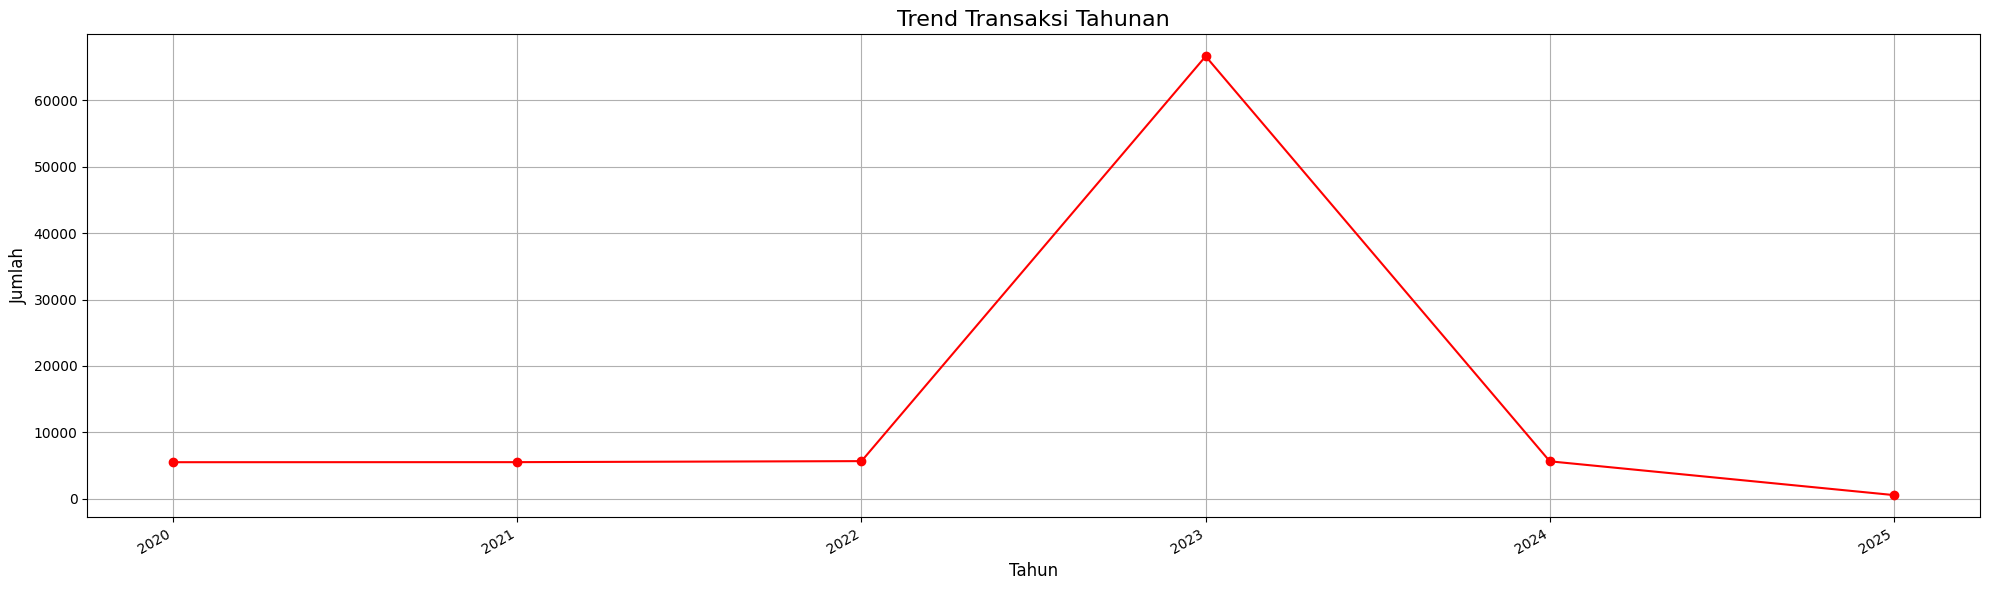

In [51]:
# Line Chart (Matplotlib) Berdasarkan Tahun

# Pastikan kolom bertipe datetime
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# Group by year
VARIABEL1 = df.groupby(df['Transaction_Date'].dt.year).size()

plt.figure(figsize=(20, 6)) # Ukuran
plt.plot(VARIABEL1.index, VARIABEL1.values, marker='o', color='red') # Color = Warna
plt.title('Tren Transaksi Tahunan', fontsize=16) # Judul
plt.xlabel('Tahun', fontsize=12) # X Keterangan
plt.ylabel('Jumlah', fontsize=12) # Y Keterangan'
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## **Histogram**


**Insight:**
> Histogram menunjukkan distribusi jumlah produk yang dibeli dalam setiap transaksi. Biasanya sebagian besar transaksi terjadi pada jumlah kecil, sedangkan transaksi dengan jumlah besar lebih jarang terjadi.

**Tindakan yang Dapat Dilakukan: **

* Membuat promo pembelian dalam jumlah banyak (bundle atau diskon kuantitas).

* Mengatur strategi stok produk berdasarkan jumlah pembelian yang paling umum.

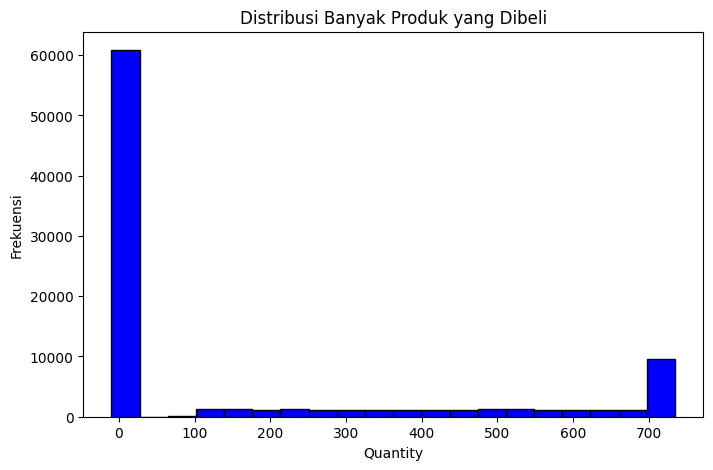

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df['Quantity'], bins=20, color='blue', edgecolor='black')
plt.title('Distribusi Banyak Produk yang Dibeli')
plt.xlabel('Quantity')
plt.ylabel('Frekuensi')
plt.show()

## **BoxPlot**

**Insight:**

> Boxplot digunakan untuk melihat penyebaran data serta mendeteksi outlier (nilai yang sangat jauh dari rata-rata) pada jumlah produk yang dibeli. Jika terdapat outlier yang tinggi, kemungkinan ada transaksi dalam jumlah yang sangat besar.

**Tindakan yang Dapat Dilakukan :**

* Memeriksa apakah outlier tersebut merupakan transaksi valid atau kesalahan input data.

* Jika valid, perusahaan dapat mengidentifikasi pelanggan dengan pembelian besar sebagai pelanggan potensial atau pelanggan bisnis.

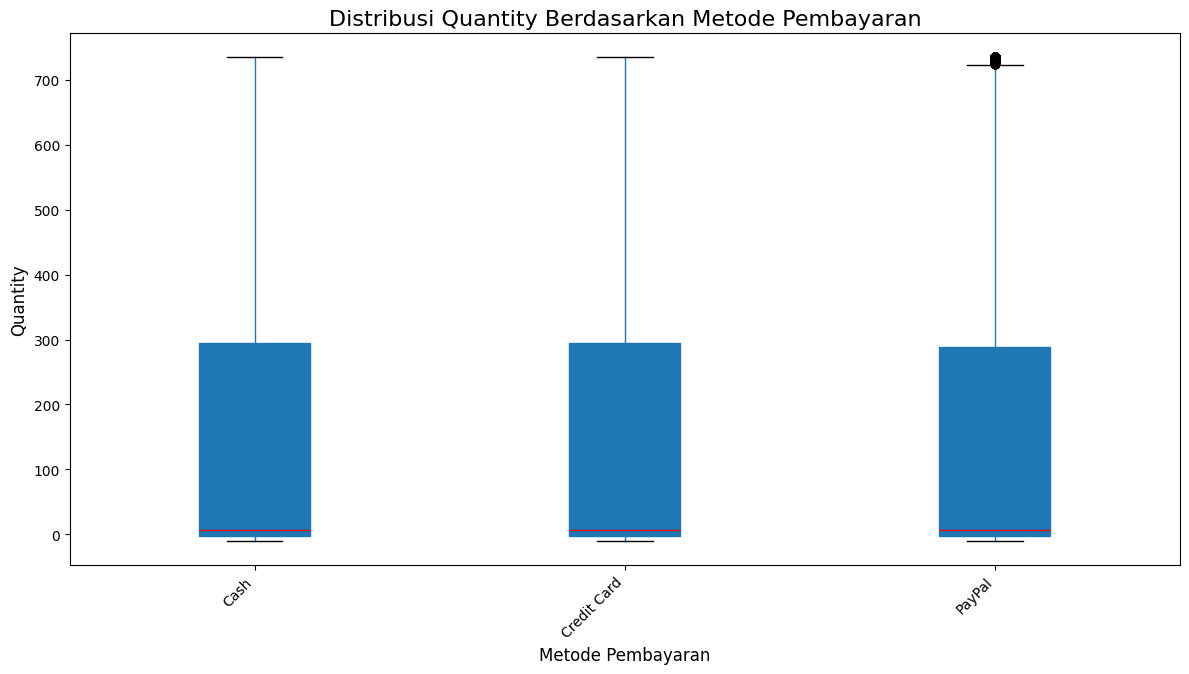

In [53]:
VARIABEL1 = df['Payment_Method'].value_counts().head(5).index
VARIABEL2 = df[df['Payment_Method'].isin(VARIABEL1)]

plt.figure(figsize=(12,7))

VARIABEL2.boxplot(column='Quantity',
                  by='Payment_Method',
                  ax=plt.gca(),
                  grid=False,
                  patch_artist=True,
                  medianprops=dict(color='red'))

plt.title('Distribusi Quantity Berdasarkan Metode Pembayaran', fontsize=16)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Quantity', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.suptitle('')

plt.tight_layout()
plt.show()

## **ScatterPlot**

**Insight:**
> Scatter plot menunjukkan hubungan antara jumlah produk yang dibeli dengan harga transaksi. Jika terlihat pola naik, berarti semakin banyak produk dibeli maka total harga juga meningkat.

**Tindakan yang Dapat Dilakukan :**

* Menggunakan informasi ini untuk membuat strategi diskon berdasarkan jumlah pembelian.

* Mengidentifikasi produk dengan nilai transaksi tinggi.

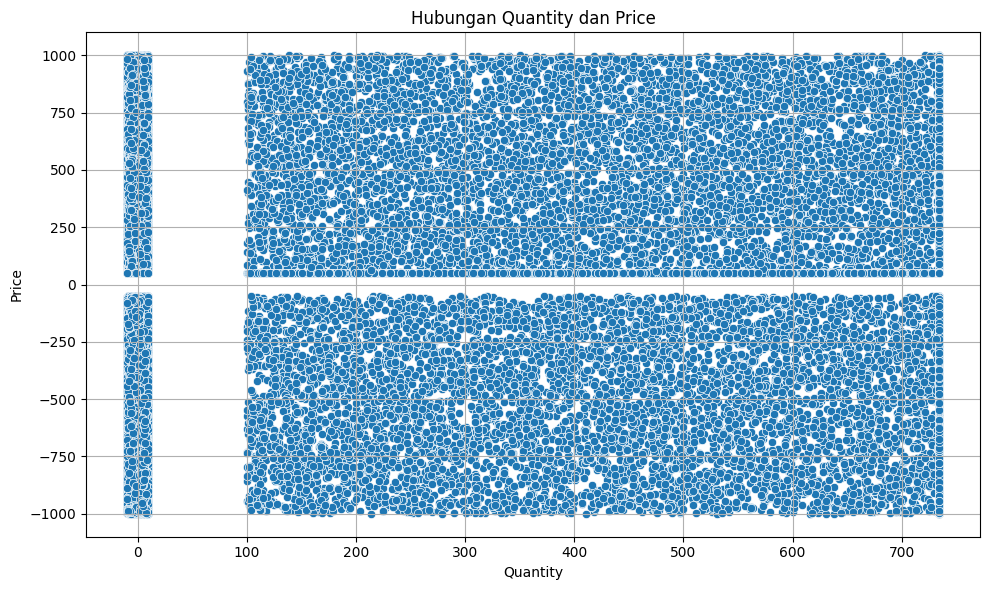

In [70]:

plt.figure(figsize=(10, 6)) # Ukuran
sns.scatterplot(x='Quantity', y='Price', data=df)
plt.title('Hubungan Quantity dan Price') # Judul
plt.xlabel('Quantity') # X Keterangan
plt.ylabel('Price') # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

## **BubbleChart**

**Insight:**
> Bubble chart dapat menunjukkan hubungan antara Quantity, Price, dan variabel lain seperti metode pembayaran atau pelanggan. Ukuran bubble membantu melihat transaksi dengan nilai besar.

**Tindakan yang Dapat Dilakukan :**

* Mengidentifikasi transaksi bernilai besar.

* Menentukan segmen pelanggan yang paling menguntungkan.

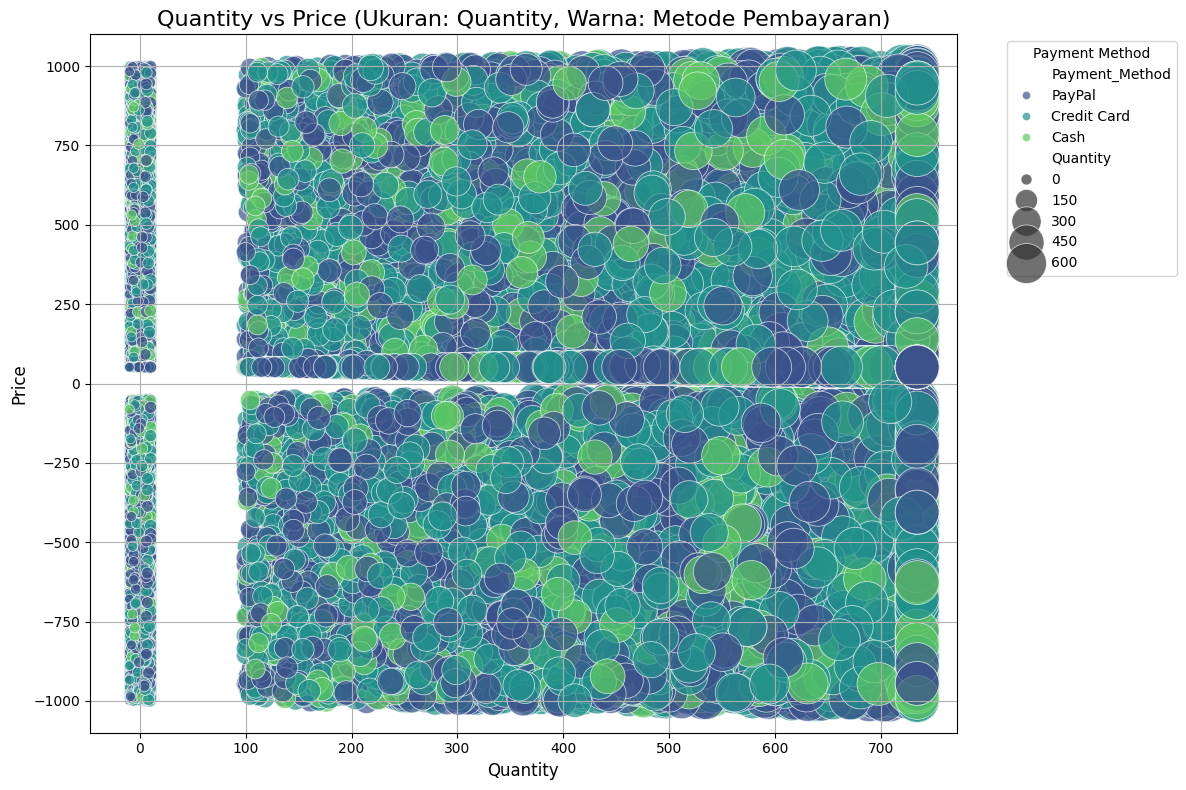

In [55]:
plt.figure(figsize=(12,8))

sns.scatterplot(x='Quantity',
                y='Price',
                size='Quantity',
                hue='Payment_Method',
                data=df,
                sizes=(50,1000),
                alpha=0.7,
                palette='viridis')

plt.title('Quantity vs Price (Ukuran: Quantity, Warna: Metode Pembayaran)', fontsize=16)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.grid(True)
plt.legend(title='Payment Method', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()

## **HeatMap**

**Insight:**
> Heatmap menunjukkan tingkat korelasi antar variabel numerik seperti Quantity dan Price. Korelasi yang tinggi menunjukkan hubungan kuat antara variabel tersebut.

**Tindakan yang Dapat Dilakukan :**

* Variabel yang memiliki korelasi tinggi dapat digunakan untuk analisis prediksi atau model machine learning.

* Membantu perusahaan memahami faktor yang paling mempengaruhi nilai transaksi.

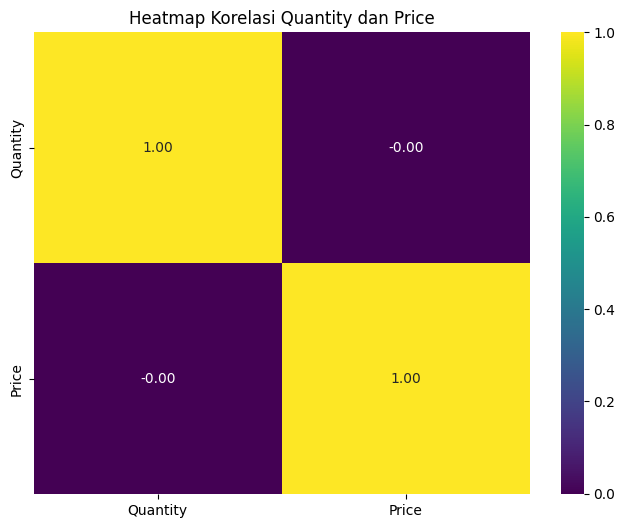

In [69]:
plt.figure(figsize=(8,6))

sns.heatmap(data=df[['Quantity','Price']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')

plt.title('Heatmap Korelasi Quantity dan Price')

plt.show()

# **Simpan File**

In [71]:
df.to_excel("Checkpoint 3.xlsx", index=False)